First five rows of dataset:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



K-Means Silhouette Score: 0.4589717867018717
Hierarchical Clustering Silhouette Score: 0.44553956399200406


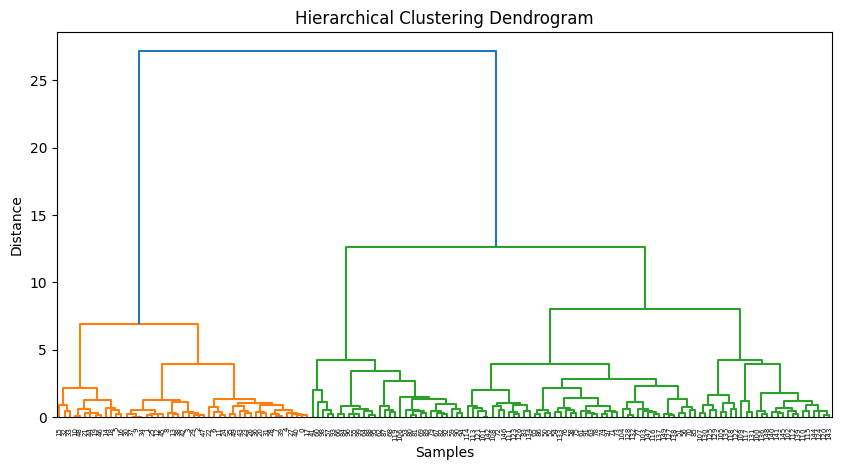

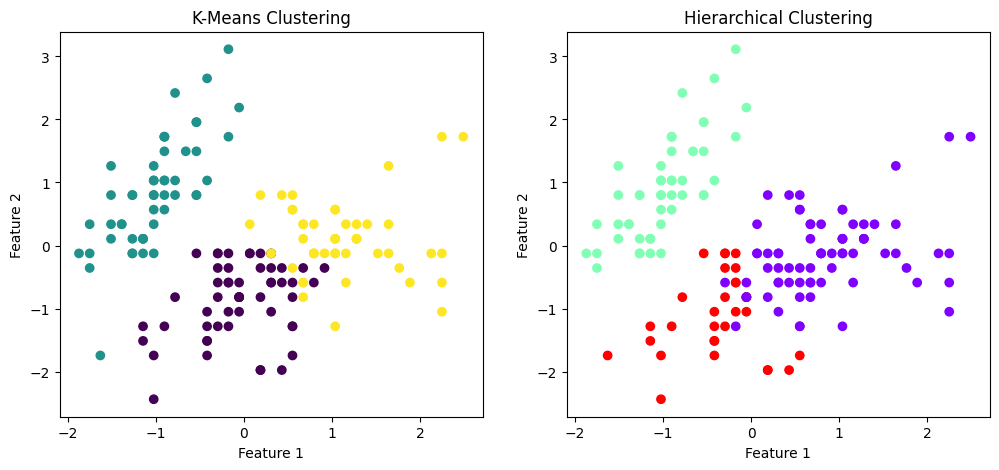

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
# Column names to be used after renaming
desired_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]
# Load the IRIS Dataset (Assuming it has a header and an 'Id' column)
data = pd.read_csv("/content/Iris.csv", header=0)

# Drop the 'Id' column as it's not a feature for clustering
if 'Id' in data.columns:
    data = data.drop('Id', axis=1)

# Rename the columns to the desired format for consistency
# Assuming the order of columns after dropping 'Id' matches desired_columns
data.columns = desired_columns

# Separate features and target
df = data.drop("species", axis=1)
print("First five rows of dataset:")
display(df.head())
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels
# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels
# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()
# Visualization of Clusters
plt.figure(figsize=(12,5))
# KMeans Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
from sklearn.cluster import DBSCAN

# DBSCAN Clustering
# Parameters (eps and min_samples) often need tuning.
# Initial values chosen based on general practice, might need adjustment for optimal performance.
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

# Evaluate DBSCAN
# Silhouette score requires at least 2 clusters and not all points as noise (-1)
if len(set(dbscan_labels)) > 1 and -1 not in dbscan_labels:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print("\nDBSCAN Silhouette Score:", dbscan_silhouette)
else:
    print("\nDBSCAN did not form enough clusters (or all points are noise) to compute a meaningful Silhouette Score.")


DBSCAN did not form enough clusters (or all points are noise) to compute a meaningful Silhouette Score.


In [4]:
# Hierarchical Clustering with Complete Linkage
hierarchical_complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
hierarchical_complete_labels = hierarchical_complete.fit_predict(X_scaled)
df['Hierarchical_Complete_Cluster'] = hierarchical_complete_labels

# Evaluate Hierarchical clustering with Complete Linkage
hierarchical_complete_silhouette = silhouette_score(X_scaled, hierarchical_complete_labels)
print("Hierarchical Clustering (Complete Linkage) Silhouette Score:", hierarchical_complete_silhouette)

Hierarchical Clustering (Complete Linkage) Silhouette Score: 0.4487911772434676


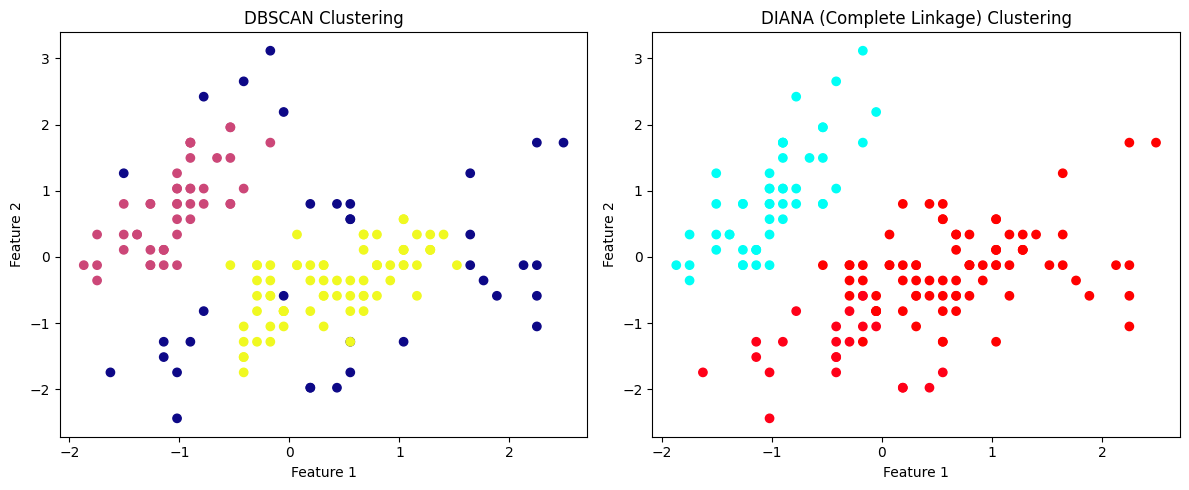

In [6]:
plt.figure(figsize=(12,5))

# DBSCAN Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=dbscan_labels, cmap='plasma')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# DIANA (Complete Linkage) Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_complete_labels, cmap='hsv')
plt.title("DIANA (Complete Linkage) Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()